# Figuras TFM 2.0

### Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

### Estilo profesional unificado

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family':          'Times New Roman',
    'font.size':            11,
    'axes.titlesize':       12,
    'axes.titleweight':     'bold',
    'axes.titlepad':        14,
    'axes.labelsize':       10,
    'axes.labelcolor':      '#2c2c2c',
    'axes.edgecolor':       '#cccccc',
    'axes.linewidth':       0.8,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.spines.left':     True,
    'axes.spines.bottom':   True,
    'axes.facecolor':       '#fafafa',
    'figure.facecolor':     'white',
    'grid.color':           '#e8e8e8',
    'grid.linewidth':       0.7,
    'grid.linestyle':       '--',
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    'xtick.color':          '#555555',
    'ytick.color':          '#555555',
    'legend.fontsize':      9,
    'legend.framealpha':    0.92,
    'legend.edgecolor':     '#cccccc',
    'legend.borderpad':     0.6,
    'savefig.dpi':          220,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
    'figure.dpi':           130,
})
 
# Paleta académica unificada
P = {
    'azul':     '#1a3a5c',
    'azul_cl':  '#4a7fb5',
    'naranja':  '#c0622a',
    'verde':    '#2a6b45',
    'rojo':     '#8b1a1a',
    'gris':     '#6b7280',
    'gris_cl':  '#d1d5db',
    'fondo':    '#f0f4f8',
}
 
def nota_fuente(fig, texto):
    """Añade nota de fuente debajo de la figura."""
    fig.text(0.98, 0.01, texto, ha='right', va='bottom',
             fontsize=8, color='#666666', style='italic',
             transform=fig.transFigure)

### Dataset

In [3]:
df = pd.DataFrame({
    'Año':              [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'Stock':            [135600,147200,163720,175400,183900,191300,196100,188440,212020,212500],
    'Brecha_Salarial':  [-10.2,-10.8,-11.3,-11.7,-12.0,-12.2,-12.3,-12.1,-12.4,-12.5],
    'Inversion_ID':     [1.22,1.22,1.18,1.20,1.24,1.25,1.41,1.43,1.44,1.45],
    'Paro_Juvenil':     [53.2,46.3,43.9,38.7,33.5,29.6,38.3,30.8,26.4,23.1],
    'Sobrecualificacion':[35.2,35.8,36.1,35.9,35.5,35.0,34.8,34.6,35.1,35.4],
    'Crec_PIB':         [1.4,3.8,3.0,3.0,2.4,2.1,-10.8,5.5,5.8,2.5],
})
 
df_paises = pd.DataFrame({
    'Pais':     ['DEU','FRA','GBR','ITA','PRT','DNK','NOR','NLD'],
    'Nombre':   ['Alemania','Francia','R. Unido','Italia',
                 'Portugal','Dinamarca','Noruega','P. Bajos'],
    'Emigrantes_Cualif':[21681,18920,17240,9840,5640,3850,2960,2890],
    'Brecha_Salarial':  [-13.40,-10.50,-12.10,-0.30,7.00,-21.80,-26.90,-16.80],
    'Inversion_ID':     [3.14,2.35,1.70,1.53,1.62,3.03,2.15,2.22],
    'Paro_Juvenil':     [6.5,18.2,11.0,28.1,20.3,10.2,9.8,8.2],
    'Salario_Hora':     [31.60,28.70,27.50,18.50,10.80,40.20,44.70,35.00],
    'Sobrecualificacion':[12.1,18.5,21.3,30.2,38.7,11.8,10.5,13.6],
})

### Figura 6.1.1 Serie temporal de stock

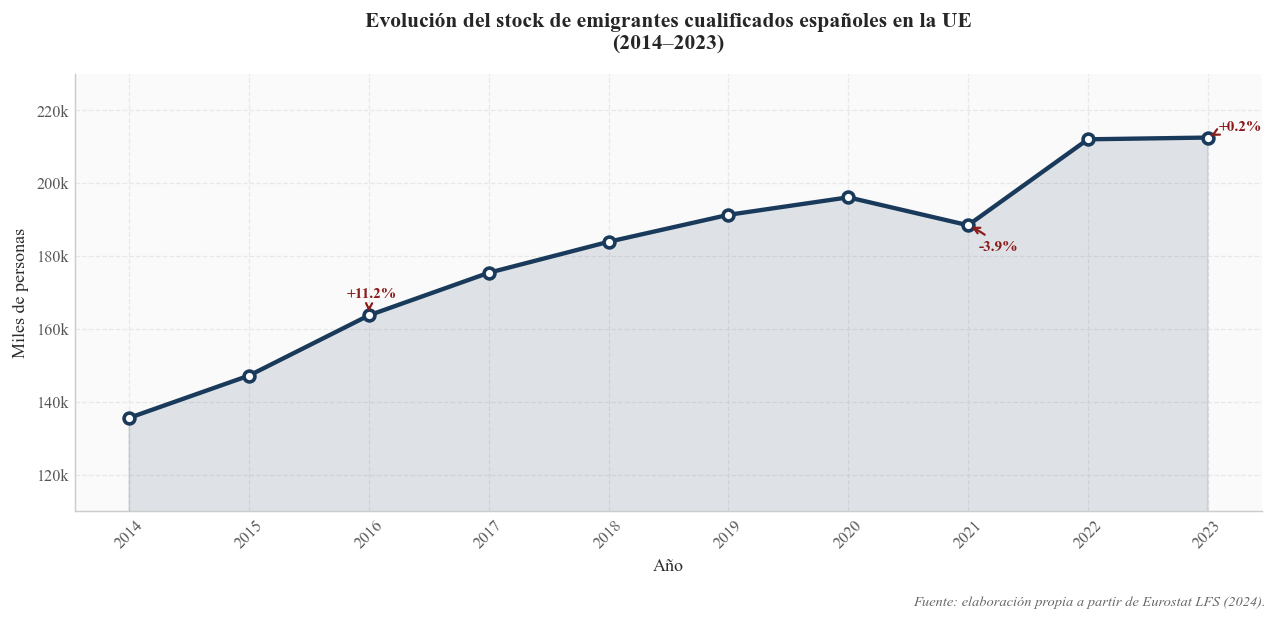

✓ fig_serie_temporal.png generada correctamente


In [5]:
# ==============================================================================
# CÓDIGO COMPLETO DE LA GRÁFICA (TODO EN LA MISMA CELDA)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. Creamos la figura y el objeto 'ax' (¡Esto es lo que te faltaba!)
fig, ax = plt.subplots(figsize=(10, 4.8))

# 2. Pintamos el fondo y la línea principal
ax.fill_between(df['Año'], df['Stock']/1000, alpha=0.12, color=P['azul'], zorder=1)
ax.plot(df['Año'], df['Stock']/1000,
        color=P['azul'], linewidth=2.4,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor=P['azul'], zorder=3)

# 3. BLOQUE DE ANOTACIONES CORREGIDO (Ya reconoce 'ax')
puntos = {2016: (-12, 10), 2021: (6, -14), 2023: (6, 4)}
for año, (dx, dy) in puntos.items():
    val_actual = df.loc[df['Año'] == año, 'Stock'].values[0]
    val_anterior = df.loc[df['Año'] == año - 1, 'Stock'].values[0]
    
    variac = ((val_actual - val_anterior) / val_anterior) * 100
    signo = '+' if variac > 0 else ''
    
    ax.annotate(f'{signo}{variac:.1f}%',
                xy=(año, val_actual / 1000), xytext=(dx, dy),
                textcoords='offset points',
                fontsize=8.5, color=P['rojo'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=P['rojo'],
                                lw=1.2, connectionstyle='arc3,rad=0.1'))

# 4. Formateo de títulos, ejes y exportación
ax.set_title('Evolución del stock de emigrantes cualificados españoles en la UE\n(2014–2023)')
ax.set_xlabel('Año')
ax.set_ylabel('Miles de personas')
ax.set_xticks(df['Año'])
ax.set_ylim(110, 230)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.tick_params(axis='x', rotation=45)

nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat LFS (2024).')
plt.tight_layout(rect=[0, 0.03, 1, 1])

# Guardamos la imagen final limpia
plt.savefig('fig_serie_temporal.png')
plt.show()
print('✓ fig_serie_temporal.png generada correctamente')

Figura 6.1.2 Matriz de Correlaciones

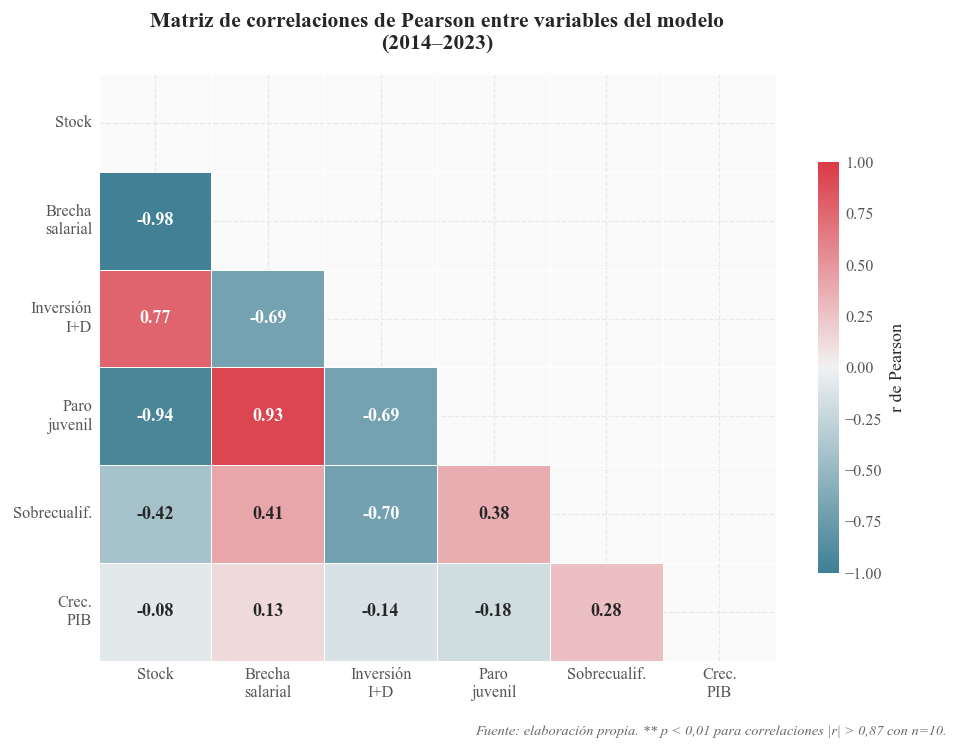

✓ fig_correlaciones.png


In [6]:
vars_c = ['Stock','Brecha_Salarial','Inversion_ID',
          'Paro_Juvenil','Sobrecualificacion','Crec_PIB']
labels = ['Stock','Brecha\nsalarial','Inversión\nI+D',
          'Paro\njuvenil','Sobrecualif.','Crec.\nPIB']
corr = df[vars_c].corr().round(2)
 
fig, ax = plt.subplots(figsize=(7.5, 5.8))
mask = np.triu(np.ones_like(corr, dtype=bool))
 
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.7, 'label': 'r de Pearson'},
            annot_kws={'size': 10, 'weight': 'bold'})
 
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)
ax.set_title('Matriz de correlaciones de Pearson entre variables del modelo\n(2014–2023)')
 
nota_fuente(fig, 'Fuente: elaboración propia. ** p < 0,01 para correlaciones |r| > 0,87 con n=10.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_correlaciones.png')
plt.show()
print('✓ fig_correlaciones.png')

### Figura 6.1.3 Diagramas de dispersión

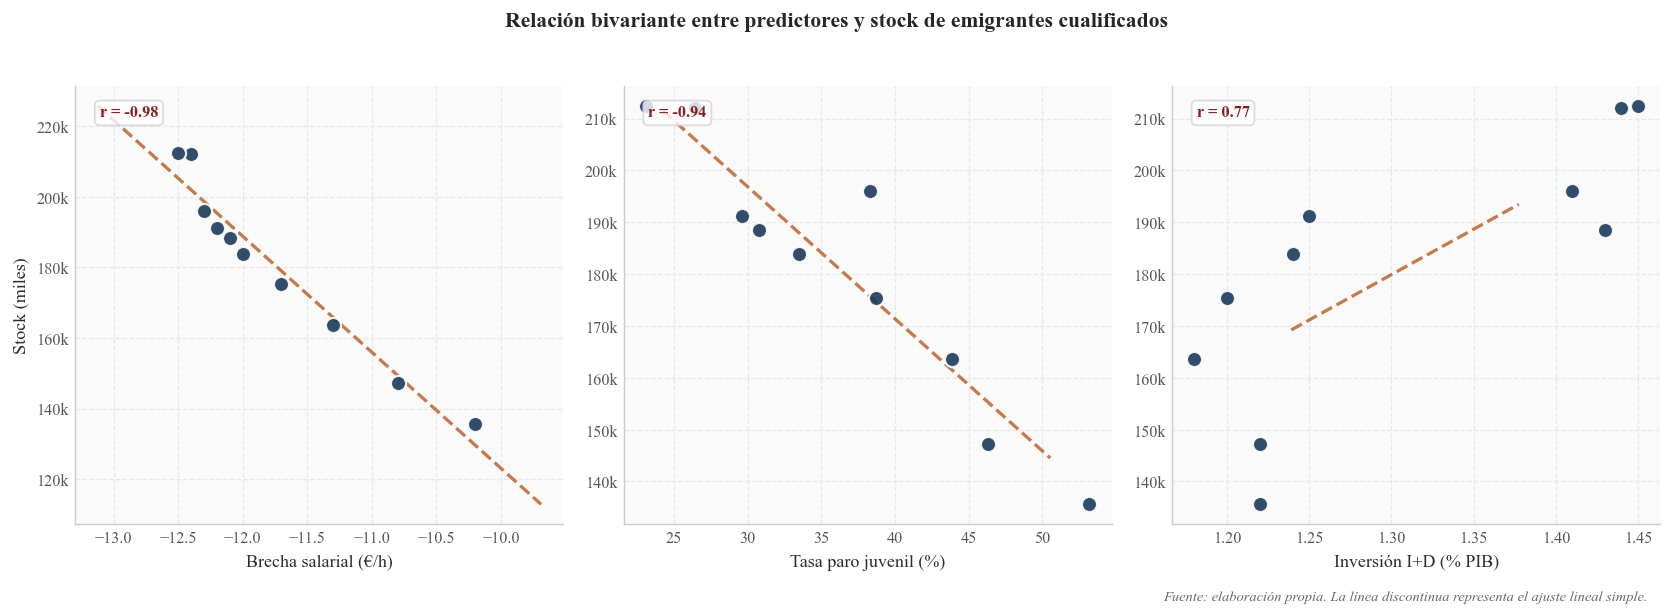

✓ fig_dispersión.png


In [7]:
vars_s = [('Brecha_Salarial','Brecha salarial (€/h)'),
          ('Paro_Juvenil','Tasa paro juvenil (%)'),
          ('Inversion_ID','Inversión I+D (% PIB)')]
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (var, label) in zip(axes, vars_s):
    ax.scatter(df[var], df['Stock']/1000,
               color=P['azul'], s=70, zorder=3,
               edgecolors='white', linewidth=1.2, alpha=0.9)
    # Línea de tendencia
    z = np.polyfit(df[var], df['Stock']/1000, 1)
    xr = np.linspace(df[var].min()*1.05, df[var].max()*0.95, 50)
    ax.plot(xr, np.poly1d(z)(xr),
            color=P['naranja'], linewidth=1.8,
            linestyle='--', alpha=0.85, zorder=2)
    # R² del ajuste lineal simple
    r = df[var].corr(df['Stock']/1000)
    ax.text(0.05, 0.93, f'r = {r:.2f}',
            transform=ax.transAxes, fontsize=9,
            color=P['rojo'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor=P['gris_cl'], alpha=0.8))
    ax.set_xlabel(label)
    ax.set_ylabel('Stock (miles)' if var == 'Brecha_Salarial' else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
 
fig.suptitle('Relación bivariante entre predictores y stock de emigrantes cualificados',
             fontsize=12, fontweight='bold', y=1.02)
nota_fuente(fig, 'Fuente: elaboración propia. La línea discontinua representa el ajuste lineal simple.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_dispersión.png')
plt.show()
print('✓ fig_dispersión.png')

### Regresión

In [8]:
y = df['Stock']
X = sm.add_constant(df[['Brecha_Salarial','Inversion_ID','Paro_Juvenil']])
modelo = sm.OLS(y, X).fit()
residuos = modelo.resid
b0 = modelo.params['const']
b_brecha = modelo.params['Brecha_Salarial']
b_id = modelo.params['Inversion_ID']
b_paro = modelo.params['Paro_Juvenil']

### Figura 6.2.1 Diagnóstico de residuos

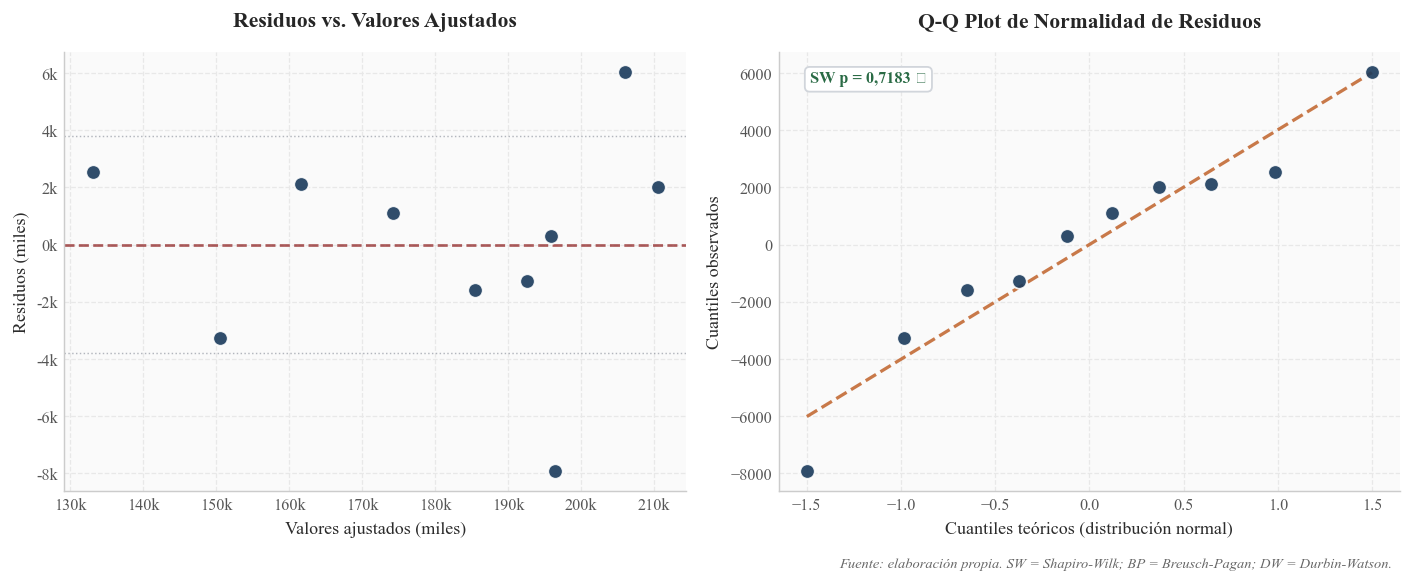

✓ fig_residuos.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
 
# Residuos vs ajustados
axes[0].scatter(modelo.fittedvalues/1000, residuos/1000,
                color=P['azul'], s=65, edgecolors='white',
                linewidth=1, zorder=3, alpha=0.9)
axes[0].axhline(0, color=P['rojo'], linewidth=1.5,
                linestyle='--', alpha=0.7, zorder=2)
# Banda ±1 sigma
s = residuos.std()/1000
axes[0].axhline(s, color=P['gris'], linewidth=0.8,
                linestyle=':', alpha=0.5)
axes[0].axhline(-s, color=P['gris'], linewidth=0.8,
                linestyle=':', alpha=0.5)
axes[0].set_xlabel('Valores ajustados (miles)')
axes[0].set_ylabel('Residuos (miles)')
axes[0].set_title('Residuos vs. Valores Ajustados')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
 
# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos)
axes[1].scatter(osm, osr, color=P['azul'], s=65,
                edgecolors='white', linewidth=1, zorder=3, alpha=0.9)
xr = np.array([min(osm), max(osm)])
axes[1].plot(xr, slope*xr + intercept,
             color=P['naranja'], linewidth=1.8,
             linestyle='--', alpha=0.85, zorder=2)
axes[1].set_xlabel('Cuantiles teóricos (distribución normal)')
axes[1].set_ylabel('Cuantiles observados')
axes[1].set_title('Q-Q Plot de Normalidad de Residuos')
axes[1].text(0.05, 0.93, f'SW p = 0,7183 ✓',
             transform=axes[1].transAxes, fontsize=9,
             color=P['verde'], fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor=P['gris_cl']))
 
nota_fuente(fig, 'Fuente: elaboración propia. SW = Shapiro-Wilk; BP = Breusch-Pagan; DW = Durbin-Watson.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_residuos.png')
plt.show()
print('✓ fig_residuos.png')

### Clustering

In [10]:
vars_cl = ['Brecha_Salarial','Inversion_ID','Paro_Juvenil',
           'Salario_Hora','Sobrecualificacion']
X_sc = MinMaxScaler().fit_transform(df_paises[vars_cl])
 
inercias, siluetas, k_range = [], [], range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_sc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_sc, lbl))
 
k_opt = k_range[np.argmax(siluetas)]
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_paises['Cluster'] = km_final.fit_predict(X_sc)

### Figura 6.3.1 Codo + Silueta

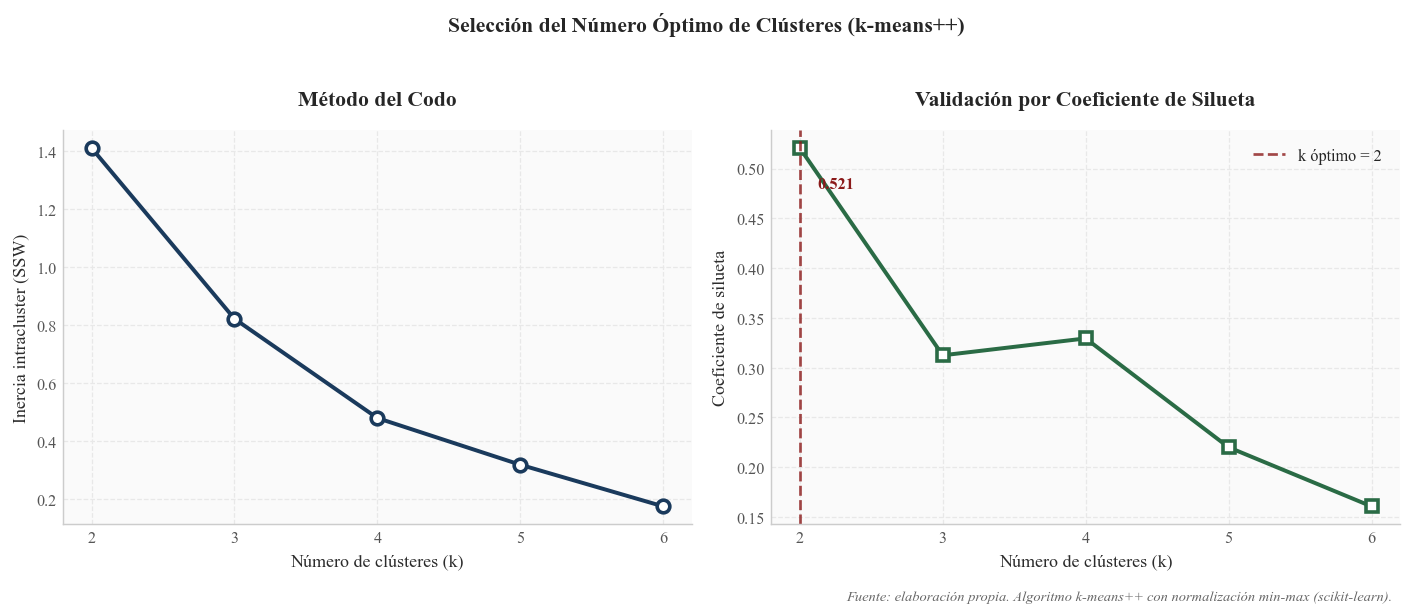

✓ fig_codo_silueta.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
 
axes[0].plot(k_range, inercias, color=P['azul'],
             marker='o', linewidth=2.2, markersize=7,
             markerfacecolor='white', markeredgewidth=2,
             markeredgecolor=P['azul'])
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia intracluster (SSW)')
axes[0].set_title('Método del Codo')
axes[0].set_xticks(k_range)
 
axes[1].plot(k_range, siluetas, color=P['verde'],
             marker='s', linewidth=2.2, markersize=7,
             markerfacecolor='white', markeredgewidth=2,
             markeredgecolor=P['verde'])
axes[1].axvline(x=k_opt, color=P['rojo'],
                linestyle='--', linewidth=1.5, alpha=0.8,
                label=f'k óptimo = {k_opt}')
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Validación por Coeficiente de Silueta')
axes[1].set_xticks(k_range)
axes[1].legend(fontsize=9)
axes[1].text(k_opt + 0.12, max(siluetas) - 0.04,
             f'{max(siluetas):.3f}',
             fontsize=9, color=P['rojo'], fontweight='bold')
 
fig.suptitle('Selección del Número Óptimo de Clústeres (k-means++)',
             fontsize=12, fontweight='bold', y=1.02)
nota_fuente(fig, 'Fuente: elaboración propia. Algoritmo k-means++ con normalización min-max (scikit-learn).')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_codo_silueta.png')
plt.show()
print('✓ fig_codo_silueta.png')
 

### Figura 6.3.2 Mapa de burbujas clústeres

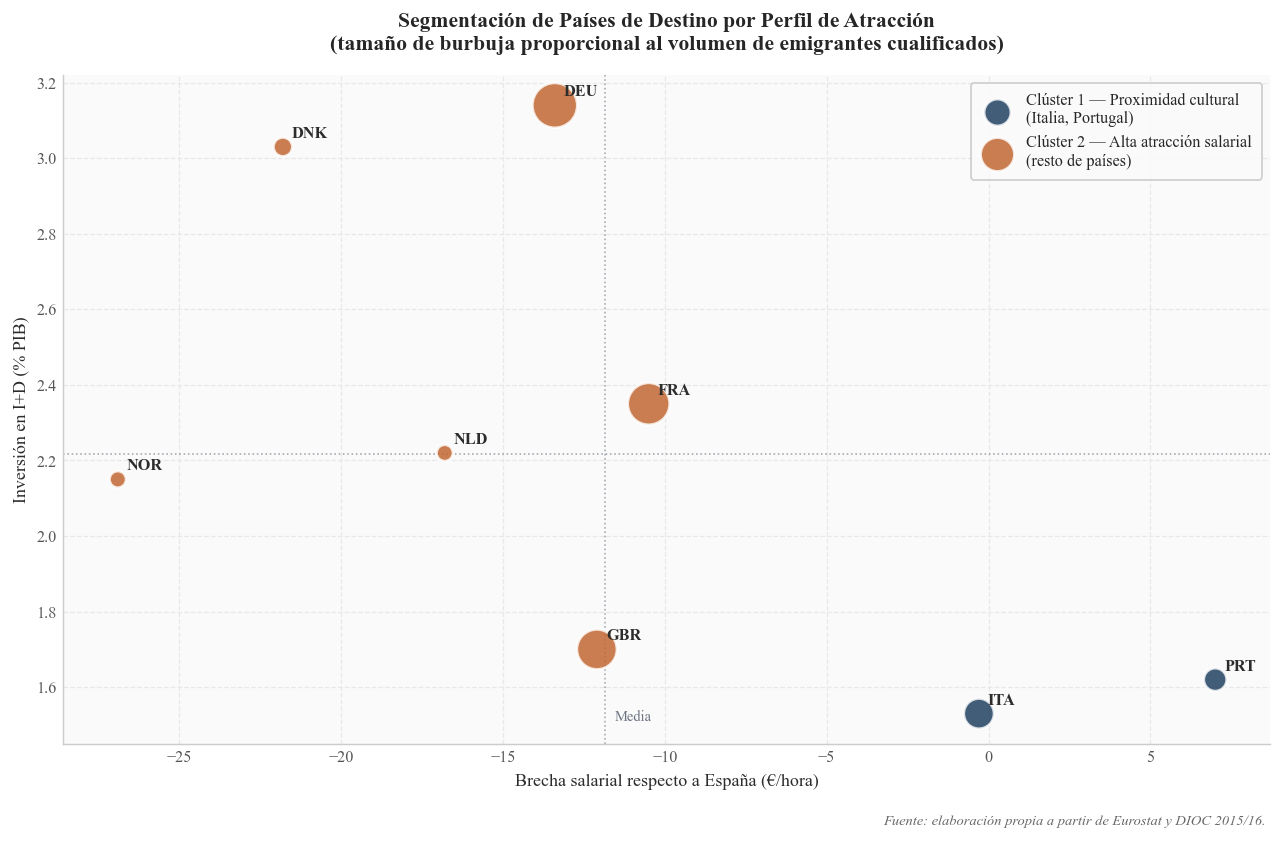

✓ fig_clusters.png


In [22]:
col_cl = {0: P['azul'], 1: P['naranja']}
lab_cl = {0: 'Clúster 1 — Proximidad cultural\n(Italia, Portugal)',
          1: 'Clúster 2 — Alta atracción salarial\n(resto de países)'}
 
fig, ax = plt.subplots(figsize=(10, 6.5))
 
for c in sorted(df_paises['Cluster'].unique()):
    sub = df_paises[df_paises['Cluster'] == c]
    ax.scatter(sub['Brecha_Salarial'], sub['Inversion_ID'],
               s=sub['Emigrantes_Cualif']/35,
               color=col_cl[c], alpha=0.82,
               edgecolors='white', linewidth=1.5,
               label=lab_cl[c], zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['Pais'],
                    xy=(row['Brecha_Salarial'], row['Inversion_ID']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold', color='#2c2c2c')
 
# Líneas de referencia en la media
ax.axhline(df_paises['Inversion_ID'].mean(),
           color=P['gris'], lw=0.9, ls=':', alpha=0.6)
ax.axvline(df_paises['Brecha_Salarial'].mean(),
           color=P['gris'], lw=0.9, ls=':', alpha=0.6)
ax.text(df_paises['Brecha_Salarial'].mean()+0.3,
        ax.get_ylim()[0] + 0.06, 'Media',
        fontsize=8, color=P['gris'])
 
ax.set_xlabel('Brecha salarial respecto a España (€/hora)')
ax.set_ylabel('Inversión en I+D (% PIB)')
ax.set_title('Segmentación de Países de Destino por Perfil de Atracción\n'
             '(tamaño de burbuja proporcional al volumen de emigrantes cualificados)')
ax.legend(loc='upper right', frameon=True, fontsize=9)
 
nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat y DIOC 2015/16.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_clusters.png')
plt.show()
print('✓ fig_clusters.png')

### Figura 6.4.1 Proyecciones de Monte Carlo

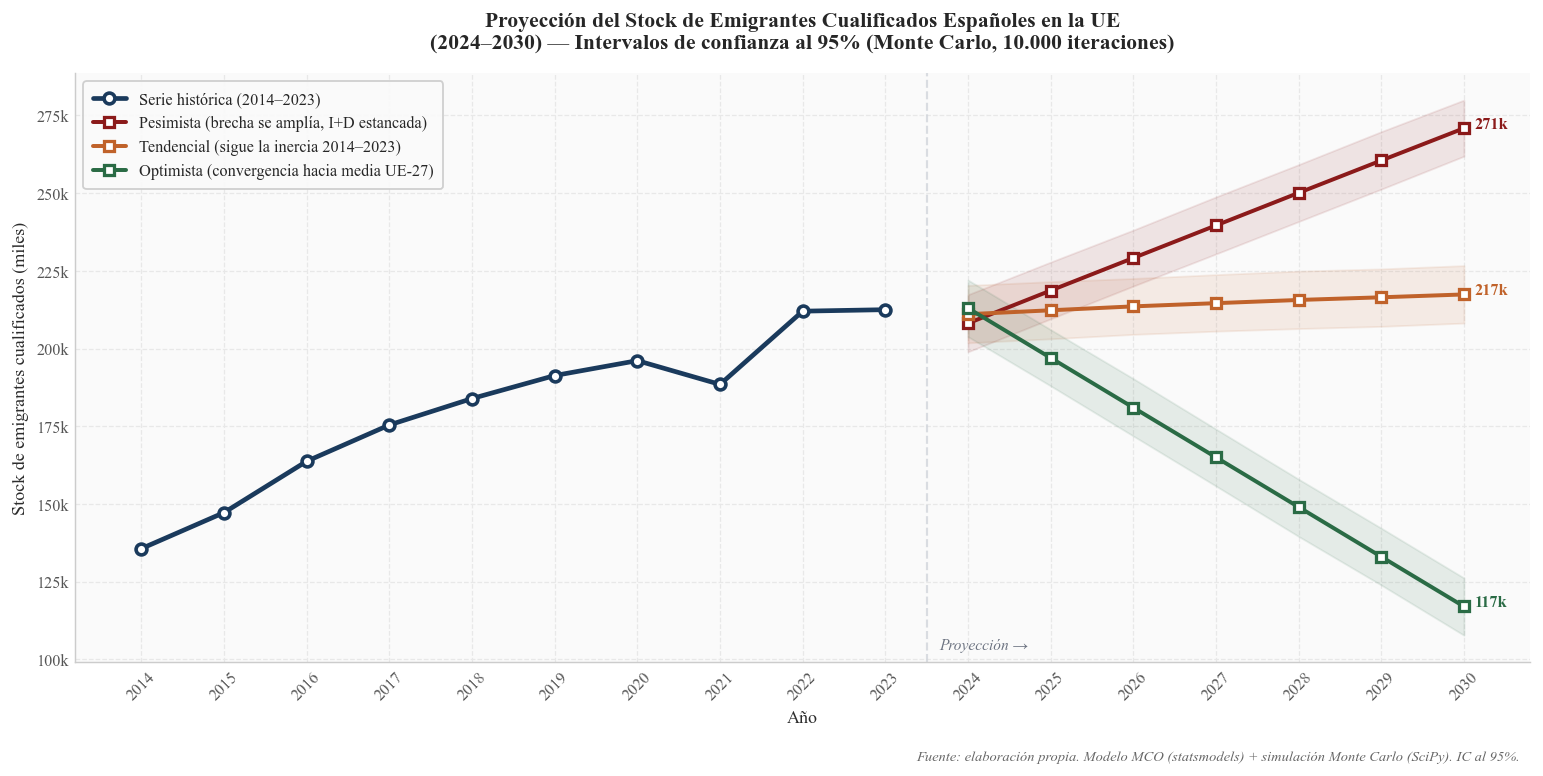

✓ fig_proyecciones.png

✓ Las 7 figuras han sido generadas con estilo académico uniforme.
  Sustituye las anteriores en el Word por estas nuevas versiones.


In [13]:
años_fut = np.arange(2024, 2031)
N_SIM = 10_000
np.random.seed(42)
sigma = np.sqrt(modelo.mse_resid)
 
escenarios = {
    'Pesimista': {
        'Brecha':  np.array([-12.5,-13.0,-13.5,-14.0,-14.5,-15.0,-15.5]),
        'ID':      np.full(7, 1.40),
        'Paro':    np.array([24.0,25.2,26.5,27.8,29.1,30.5,32.0]),
        'color':   P['rojo'], 'ls': '-',
        'label':   'Pesimista (brecha se amplía, I+D estancada)',
    },
    'Tendencial': {
        'Brecha':  np.full(7, -12.5),
        'ID':      np.array([1.46,1.48,1.50,1.52,1.54,1.56,1.58]),
        'Paro':    np.array([22.8,21.9,21.0,20.5,20.0,19.8,19.5]),
        'color':   P['naranja'], 'ls': '-',
        'label':   'Tendencial (sigue la inercia 2014–2023)',
    },
    'Optimista': {
        'Brecha':  np.array([-12.5,-11.5,-10.5,-9.5,-8.5,-7.5,-6.5]),
        'ID':      np.array([1.50,1.65,1.80,1.95,2.10,2.25,2.40]),
        'Paro':    np.array([22.0,20.5,19.0,17.5,16.0,14.5,13.0]),
        'color':   P['verde'], 'ls': '-',
        'label':   'Optimista (convergencia hacia media UE-27)',
    },
}
 
fig, ax = plt.subplots(figsize=(12, 6))
 
# Serie histórica
ax.plot(df['Año'], df['Stock']/1000,
        color=P['azul'], linewidth=2.6,
        marker='o', markersize=6,
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=P['azul'],
        label='Serie histórica (2014–2023)', zorder=5)
 
for nombre, esc in escenarios.items():
    pred = b0 + b_brecha*esc['Brecha'] + b_id*esc['ID'] + b_paro*esc['Paro']
    sims = np.zeros((N_SIM, len(años_fut)))
    for t in range(len(años_fut)):
        sims[:, t] = pred[t] + np.random.normal(0, sigma, N_SIM)
    lo = np.percentile(sims, 2.5, axis=0)
    hi = np.percentile(sims, 97.5, axis=0)
 
    ax.plot(años_fut, pred/1000,
            color=esc['color'], linewidth=2.2,
            marker='s', markersize=5,
            markerfacecolor='white', markeredgewidth=1.8,
            markeredgecolor=esc['color'],
            label=esc['label'], zorder=4)
    ax.fill_between(años_fut, lo/1000, hi/1000,
                    alpha=0.10, color=esc['color'], zorder=2)
    # Valor final anotado
    ax.annotate(f"{pred[-1]/1000:.0f}k",
                xy=(2030, pred[-1]/1000),
                xytext=(6, 0), textcoords='offset points',
                fontsize=9, color=esc['color'], fontweight='bold')
 
# Línea divisoria histórico/proyección
ax.axvline(2023.5, color=P['gris_cl'], linewidth=1.2,
           linestyle='--', alpha=0.8, zorder=1)
ax.text(2023.65, ax.get_ylim()[0]+4, 'Proyección →',
        fontsize=8.5, color=P['gris'], style='italic')
 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.set_xlabel('Año')
ax.set_ylabel('Stock de emigrantes cualificados (miles)')
ax.set_title('Proyección del Stock de Emigrantes Cualificados Españoles en la UE\n'
             '(2024–2030) — Intervalos de confianza al 95% (Monte Carlo, 10.000 iteraciones)')
ax.set_xticks(list(df['Año']) + list(años_fut))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', frameon=True, fontsize=9)
 
nota_fuente(fig, 'Fuente: elaboración propia. Modelo MCO (statsmodels) + simulación Monte Carlo (SciPy). IC al 95%.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_proyecciones.png')
plt.show()
print('✓ fig_proyecciones.png')
 
print('\n✓ Las 7 figuras han sido generadas con estilo académico uniforme.')
print('  Sustituye las anteriores en el Word por estas nuevas versiones.')

## Figuras Capítulo 3

In [14]:
import os
 
DATOS    = r"C:\Users\carlo\OneDrive\Desktop\figuras_tfm\DATOS_Y_GRAFICOS.xlsx"
SALARIOS = r"C:\Users\carlo\OneDrive\Desktop\figuras_tfm\mapa_ue_salarios.xlsx"
 
try:
    df_eurostat = pd.read_excel(DATOS, sheet_name='Eurostat', header=1, skiprows=[2])
    df_eurostat = df_eurostat.iloc[:, :2].dropna()
    df_eurostat.columns = ['Año', 'Stock']
    df_eurostat = df_eurostat[df_eurostat['Año'].astype(str).str.match(r'^\d{4}$')]
    df_eurostat['Año']  = df_eurostat['Año'].astype(int)
    df_eurostat['Stock'] = df_eurostat['Stock'].astype(float)
 
    df_raw2 = pd.read_excel(DATOS, sheet_name='Eurostat 2', header=None)
    df_comp = df_raw2.iloc[4:14, [0,1,3,5,7]].copy()
    df_comp.columns = ['Año','España','Alemania','Francia','Italia']
    df_comp['Año'] = df_comp['Año'].astype(int)
    for col in ['España','Alemania','Francia','Italia']:
        df_comp[col] = pd.to_numeric(df_comp[col], errors='coerce')
 
    df_raw4 = pd.read_excel(DATOS, sheet_name='punto 7', header=None)
    df_pct = df_raw4.iloc[3:7, [6,7,8]].copy()
    df_pct.columns = ['País','2008','2022']
    df_pct['2008'] = pd.to_numeric(df_pct['2008'], errors='coerce') * 100
    df_pct['2022'] = pd.to_numeric(df_pct['2022'], errors='coerce') * 100
 
    df_sal = pd.read_excel(SALARIOS, header=1)
    df_sal.columns = ['País','Salario']
    df_sal = df_sal.dropna(subset=['País'])
    iso_map = {
        'ESPAÑA':'ESP','PORTUGAL':'PRT','FRANCIA':'FRA','ITALIA':'ITA',
        'GRECIA':'GRC','MALTA':'MLT','BULGARIA':'BGR','RUMANIA':'ROU',
        'HUNGRÍA':'HUN','AUSTRIA':'AUT','CROACIA':'HRV','ESLOVENIA':'SVN',
        'ESLOVAQUIA':'SVK','REPUBLICA CHECA':'CZE','REPÚBLICA CHECA':'CZE',
        'POLONIA':'POL','LITUANIA':'LTU','LETONIA':'LVA','ESTONIA':'EST',
        'ALEMANIA':'DEU','DINAMARCA':'DNK','PAÍSES BAJOS':'NLD',
        'BÉLGICA':'BEL','IRLANDA':'IRL','ISLANDIA':'ISL','NORUEGA':'NOR',
        'SUECIA':'SWE','FINLANDIA':'FIN','LUXEMBURGO':'LUX',
    }
    df_sal['ISO'] = df_sal['País'].str.upper().str.strip().map(iso_map)
    df_sal = df_sal.dropna(subset=['ISO'])
    print("✓ Datos Excel cargados correctamente")
    excel_ok = True
 
except Exception as e:
    print(f"⚠ Excel no encontrado ({e}). Usando datos de ejemplo.")
    excel_ok = False
    df_eurostat = df[['Año']].copy()
    df_eurostat['Stock'] = df['Stock']/1000
    df_comp = pd.DataFrame({
        'Año':    [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023],
        'España': [135.6,138.9,154.1,162.3,165.8,174.6,175.0,167.1,191.5,212.3],
        'Alemania':[335.0,335.5,345.0,358.0,370.0,385.0,388.0,394.0,415.0,430.0],
        'Francia': [265.0,258.0,252.0,265.0,290.0,310.0,320.0,325.0,335.0,340.0],
        'Italia':  [248.0,258.0,260.0,290.0,330.0,375.0,380.0,355.0,410.0,448.0],
    })
    df_pct = pd.DataFrame({
        'País':  ['ESPAÑA','ALEMANIA','ITALIA','FRANCIA'],
        '2008':  [20.0, 28.0, 11.0, 34.0],
        '2022':  [43.0, 38.0, 15.0, 45.0],
    })

⚠ Excel no encontrado ([Errno 2] No such file or directory: 'C:\\Users\\carlo\\OneDrive\\Desktop\\figuras_tfm\\DATOS_Y_GRAFICOS.xlsx'). Usando datos de ejemplo.


### Figura 2.1.1 Stock Histórico España

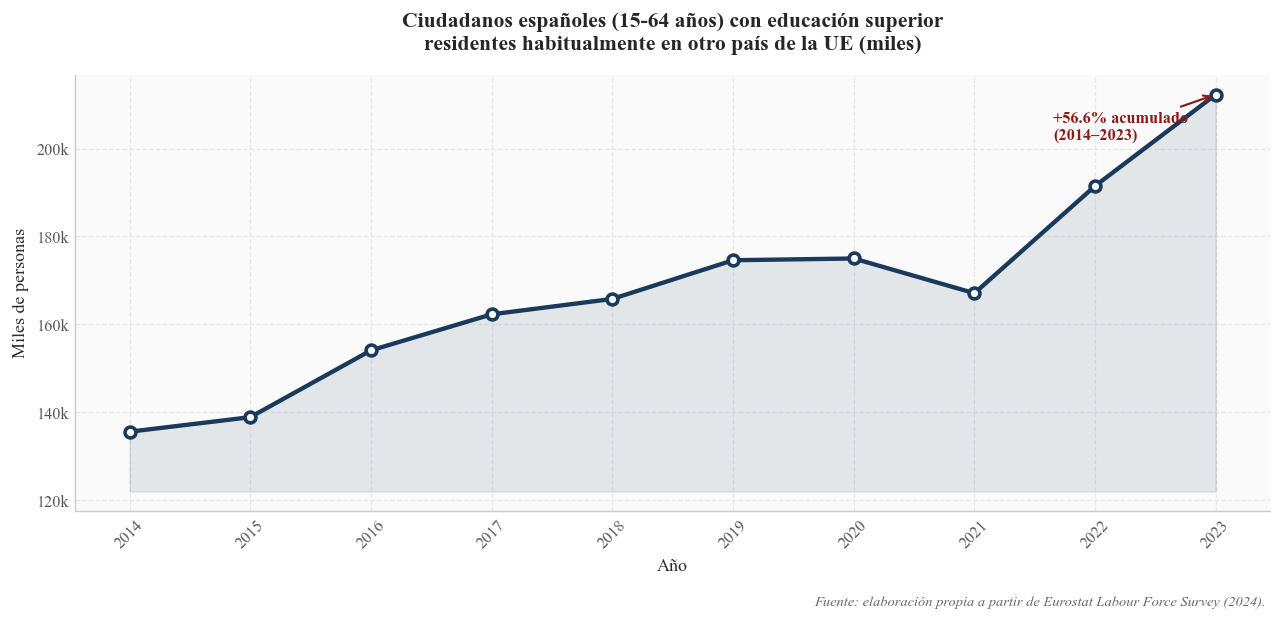

✓ fig_2_1_1_stock_espana.png


In [15]:
años_e = df_eurostat['Año'].tolist() if excel_ok else df_comp['Año'].tolist()
stock_e = df_eurostat['Stock'].tolist() if excel_ok else df_comp['España'].tolist()
 
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(años_e, stock_e, min(stock_e)*0.90, alpha=0.10, color=P['azul'])
ax.plot(años_e, stock_e, color=P['azul'], linewidth=2.4,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor=P['azul'], zorder=3)
 
variac_total = (stock_e[-1]-stock_e[0])/stock_e[0]*100
ax.annotate(f'+{variac_total:.1f}% acumulado\n(2014–2023)',
            xy=(años_e[-1], stock_e[-1]),
            xytext=(-90, -25), textcoords='offset points',
            fontsize=9, color=P['rojo'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=P['rojo'], lw=1.2))
 
ax.set_title('Ciudadanos españoles (15-64 años) con educación superior\nresidentes habitualmente en otro país de la UE (miles)')
ax.set_xlabel('Año')
ax.set_ylabel('Miles de personas')
ax.set_xticks(años_e)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.tick_params(axis='x', rotation=45)
nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat Labour Force Survey (2024).')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_2_1_1_stock_espana.png')
plt.show()
print('✓ fig_2_1_1_stock_espana.png')

### Figura 2.2.1 Mapa de Salarios

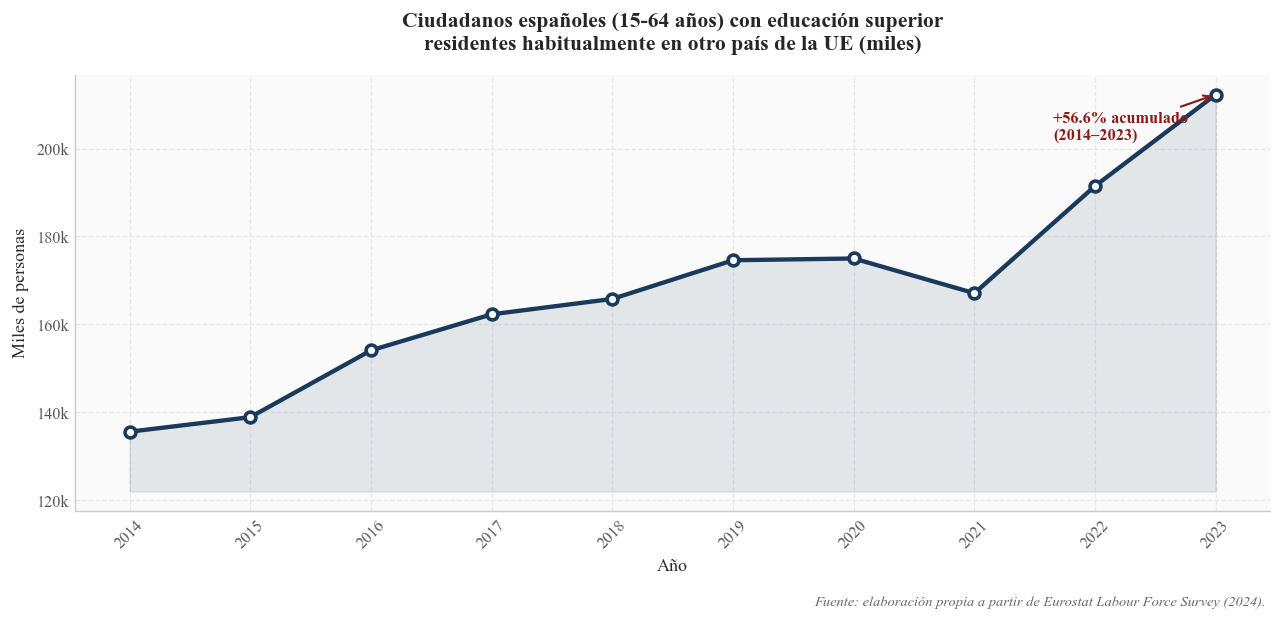

✓ fig_2_1_1_stock_espana.png


In [16]:
años_e = df_eurostat['Año'].tolist() if excel_ok else df_comp['Año'].tolist()
stock_e = df_eurostat['Stock'].tolist() if excel_ok else df_comp['España'].tolist()
 
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(años_e, stock_e, min(stock_e)*0.90, alpha=0.10, color=P['azul'])
ax.plot(años_e, stock_e, color=P['azul'], linewidth=2.4,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor=P['azul'], zorder=3)
 
variac_total = (stock_e[-1]-stock_e[0])/stock_e[0]*100
ax.annotate(f'+{variac_total:.1f}% acumulado\n(2014–2023)',
            xy=(años_e[-1], stock_e[-1]),
            xytext=(-90, -25), textcoords='offset points',
            fontsize=9, color=P['rojo'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=P['rojo'], lw=1.2))
 
ax.set_title('Ciudadanos españoles (15-64 años) con educación superior\nresidentes habitualmente en otro país de la UE (miles)')
ax.set_xlabel('Año')
ax.set_ylabel('Miles de personas')
ax.set_xticks(años_e)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax.tick_params(axis='x', rotation=45)
nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat Labour Force Survey (2024).')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_2_1_1_stock_espana.png')
plt.show()
print('✓ fig_2_1_1_stock_espana.png')

### Figura 2.2.1 Mapa de Salarios

In [17]:
%pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


In [18]:
try:
    import plotly.express as px
    import plotly.io as pio
 
    if not excel_ok:
        df_sal = pd.DataFrame({
            'ISO': ['NOR','ISL','DNK','LUX','SWE','NLD','BEL','FIN',
                    'AUT','DEU','FRA','IRL','GBR','ITA','ESP','CYP',
                    'SVN','CZE','SVK','EST','POL','HRV','LVA','HUN',
                    'LTU','GRC','PRT','ROU','BGR'],
            'Salario': [47.2,43.5,40.2,39.8,35.1,35.0,34.5,33.2,
                        32.1,31.6,28.7,27.8,27.5,18.5,19.8,15.2,
                        14.8,13.2,12.1,12.0,11.4,10.5,10.2,10.1,
                        9.8,9.5,10.8,8.8,8.1],
            'País': ['Noruega','Islandia','Dinamarca','Luxemburgo',
                     'Suecia','Países Bajos','Bélgica','Finlandia',
                     'Austria','Alemania','Francia','Irlanda','RU',
                     'Italia','España','Chipre','Eslovenia','R. Checa',
                     'Eslovaquia','Estonia','Polonia','Croacia',
                     'Letonia','Hungría','Lituania','Grecia','Portugal',
                     'Rumania','Bulgaria'],
        })
 
    fig_map = px.choropleth(
        df_sal, locations='ISO', color='Salario',
        color_continuous_scale=[
            [0.0, '#f7fbff'],
            [0.3, '#9ecae1'],
            [0.6, '#3182bd'],
            [1.0, '#08306b'],
        ],
        range_color=[df_sal['Salario'].min(), df_sal['Salario'].max()],
        scope='europe',
        labels={'Salario': '€/hora'},
        hover_name='País' if 'País' in df_sal.columns else 'ISO',
        hover_data={'Salario': ':.2f', 'ISO': False},
    )
    fig_map.update_layout(
        title=dict(
            text='Salario Medio por Hora en Europa (€/hora)',
            font=dict(family='Times New Roman', size=14),
            x=0.5, xanchor='center'
        ),
        font=dict(family='Times New Roman', size=11),
        coloraxis_colorbar=dict(
            title='€/hora',
            tickvals=[8,15,25,35,47],
            ticktext=['8€','15€','25€','35€','47€'],
            thickness=14, len=0.7,
        ),
        geo=dict(
            showframe=False, showcoastlines=False,
            projection_type='natural earth',
            showland=True, landcolor='#f2f2f2',
            showocean=True, oceancolor='#e8f4f8',
            showcountries=True, countrycolor='white',
            countrywidth=0.5,
        ),
        margin=dict(l=0, r=0, t=50, b=30),
        paper_bgcolor='white',
        annotations=[dict(
            text='Fuente: elaboración propia a partir de Eurostat Structure of Earnings Survey (2022).',
            x=0.5, y=-0.04, xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=9, color='#666666', family='Times New Roman'),
            xanchor='center'
        )]
    )
    pio.write_image(fig_map, 'fig_2_2_1_mapa_salarios.png',
                    width=950, height=580, scale=2)
    print('✓ fig_2_2_1_mapa_salarios.png')
except ImportError:
    print('⚠ Instala plotly y kaleido: pip install plotly kaleido')

✓ fig_2_2_1_mapa_salarios.png


### Figura 2.4.1 Comparativa 4 países

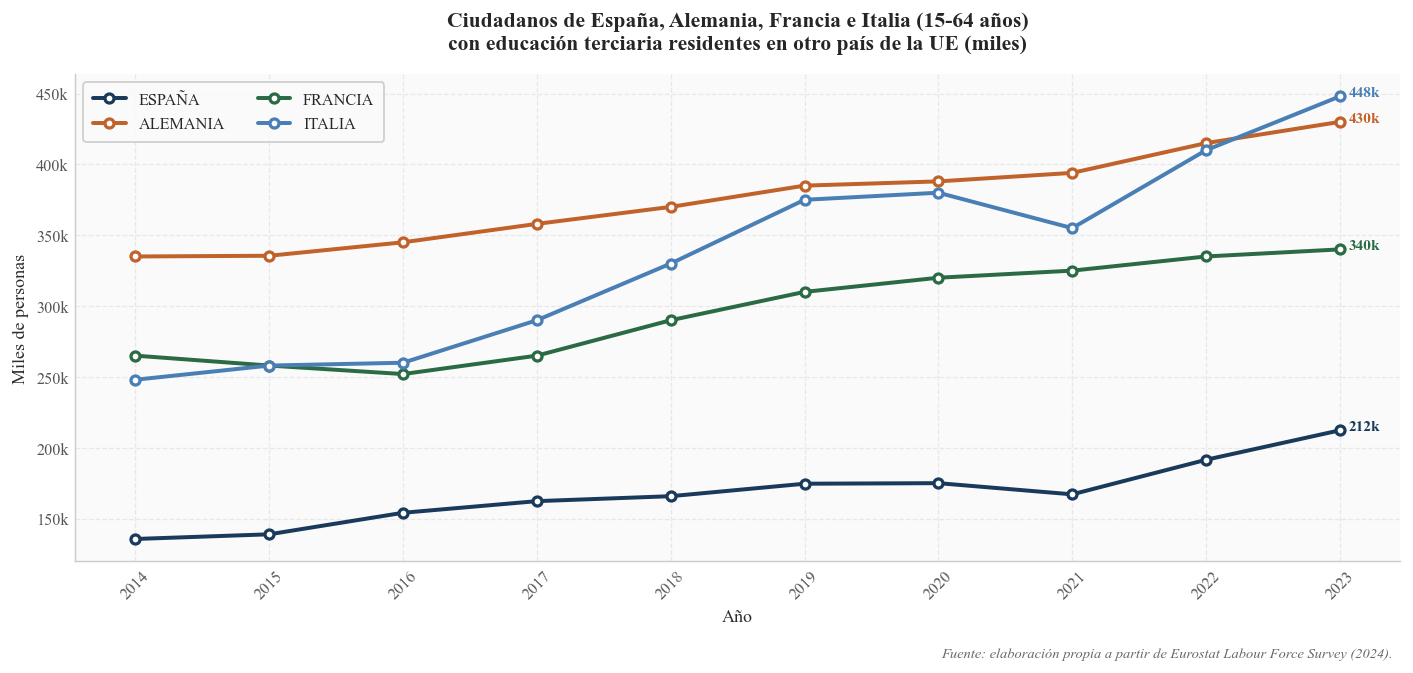

✓ fig_2_4_1_comparativa_paises.png


In [21]:
años_c = df_comp['Año'].tolist()
series = {
    'España':   P['azul'],
    'Alemania': P['naranja'],
    'Francia':  P['verde'],
    'Italia':   P['azul_cl'],
}
 
fig, ax = plt.subplots(figsize=(11, 5.2))
for pais, color in series.items():
    vals = df_comp[pais].tolist()
    ax.plot(años_c, vals, color=color, linewidth=2.2,
            marker='o', markersize=5,
            markerfacecolor='white', markeredgewidth=1.8,
            markeredgecolor=color, label=pais.upper(), zorder=3)
    ax.annotate(f'{vals[-1]:.0f}k',
                xy=(años_c[-1], vals[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold')
 
ax.set_title('Ciudadanos de España, Alemania, Francia e Italia (15-64 años)\n'
             'con educación terciaria residentes en otro país de la UE (miles)')
ax.set_xlabel('Año')
ax.set_ylabel('Miles de personas')
ax.set_xticks(años_c)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', frameon=True, fontsize=9, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat Labour Force Survey (2024).')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_2_4_1_comparativa_paises.png')
plt.show()
print('✓ fig_2_4_1_comparativa_paises.png')

### Figura 2.4.2 % terciarios 2008 vs 2022

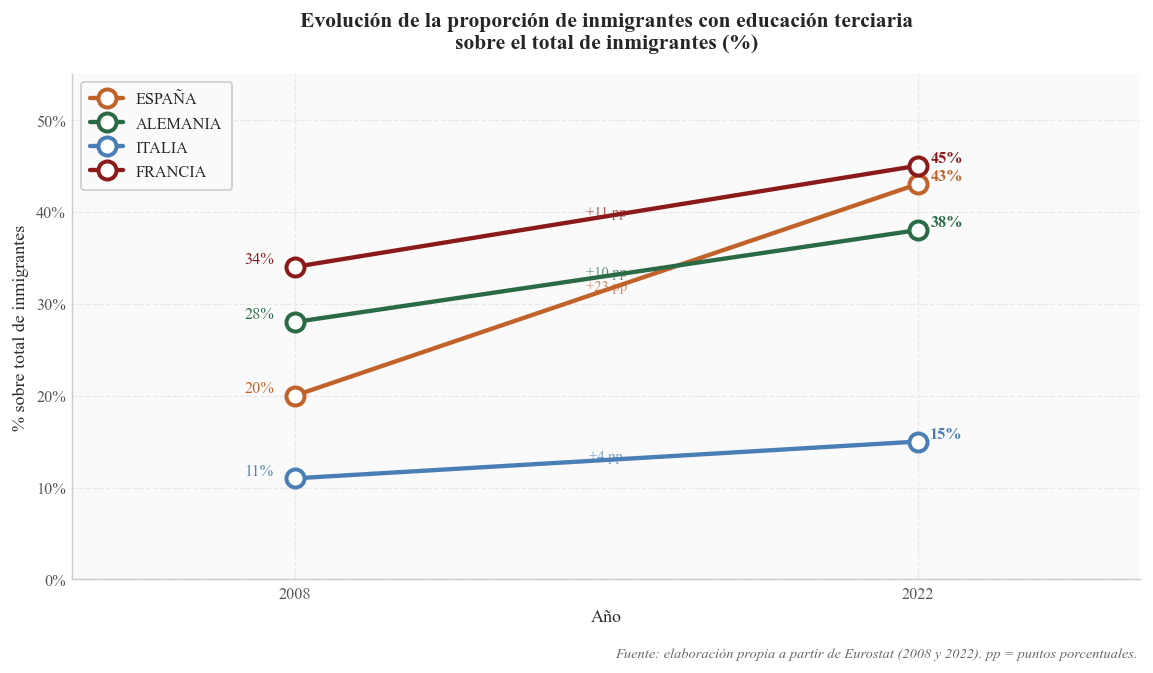

✓ fig_2_4_2_pct_terciarios.png

══════════════════════════════════════════════════════
✓ TODAS LAS FIGURAS GENERADAS (11 en total)
══════════════════════════════════════════════════════

Figuras Cap 3 (sustituye las actuales en Word):
  fig_2_1_1_stock_espana.png      → Figura 2.1.1
  fig_2_2_1_mapa_salarios.png     → Figura 2.2.1
  fig_2_4_1_comparativa_paises.png → Figura 2.4.1
  fig_2_4_2_pct_terciarios.png    → Figura 2.4.2

Figuras Cap 6 (coloca donde indican los placeholders):
  fig_serie_temporal.png   → Figura 6.1.1
  fig_correlaciones.png    → Figura 6.1.2
  fig_dispersión.png       → Figura 6.1.3
  fig_residuos.png         → Figura 6.2.1
  fig_codo_silueta.png     → Figura 6.3.1
  fig_clusters.png         → Figura 6.3.2

Figura Cap 7:
  fig_proyecciones.png     → Figura 7.x (tras tabla proyecciones)


In [20]:
col_paises = {
    'ESPAÑA':   P['naranja'],
    'ALEMANIA': P['verde'],
    'ITALIA':   P['azul_cl'],
    'FRANCIA':  P['rojo'],
}
 
fig, ax = plt.subplots(figsize=(9, 5.2))
for _, row in df_pct.iterrows():
    pais  = str(row['País']).upper().strip()
    v2008 = row['2008']
    v2022 = row['2022']
    color = col_paises.get(pais, P['gris'])
 
    ax.plot([2008, 2022], [v2008, v2022],
            color=color, linewidth=2.4,
            marker='o', markersize=10,
            markerfacecolor='white', markeredgewidth=2.2,
            markeredgecolor=color, zorder=3,
            label=pais)
    # Etiquetas
    ax.annotate(f'{v2008:.0f}%',
                xy=(2008, v2008), xytext=(-28, 2),
                textcoords='offset points',
                fontsize=9, color=color)
    ax.annotate(f'+{v2022-v2008:.0f} pp',
                xy=(2015, (v2008+v2022)/2),
                fontsize=8, color=color, alpha=0.75,
                ha='center')
    ax.annotate(f'{v2022:.0f}%',
                xy=(2022, v2022), xytext=(7, 2),
                textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')
 
ax.set_title('Evolución de la proporción de inmigrantes con educación terciaria\nsobre el total de inmigrantes (%)')
ax.set_xlabel('Año')
ax.set_ylabel('% sobre total de inmigrantes')
ax.set_xticks([2008, 2022])
ax.set_xlim(2003, 2027)
ax.set_ylim(0, 55)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(loc='upper left', frameon=True, fontsize=9)
nota_fuente(fig, 'Fuente: elaboración propia a partir de Eurostat (2008 y 2022). pp = puntos porcentuales.')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig_2_4_2_pct_terciarios.png')
plt.show()
print('✓ fig_2_4_2_pct_terciarios.png')
 
 
print('\n══════════════════════════════════════════════════════')
print('✓ TODAS LAS FIGURAS GENERADAS (11 en total)')
print('══════════════════════════════════════════════════════')
print('\nFiguras Cap 3 (sustituye las actuales en Word):')
print('  fig_2_1_1_stock_espana.png      → Figura 2.1.1')
print('  fig_2_2_1_mapa_salarios.png     → Figura 2.2.1')
print('  fig_2_4_1_comparativa_paises.png → Figura 2.4.1')
print('  fig_2_4_2_pct_terciarios.png    → Figura 2.4.2')
print('\nFiguras Cap 6 (coloca donde indican los placeholders):')
print('  fig_serie_temporal.png   → Figura 6.1.1')
print('  fig_correlaciones.png    → Figura 6.1.2')
print('  fig_dispersión.png       → Figura 6.1.3')
print('  fig_residuos.png         → Figura 6.2.1')
print('  fig_codo_silueta.png     → Figura 6.3.1')
print('  fig_clusters.png         → Figura 6.3.2')
print('\nFigura Cap 7:')
print('  fig_proyecciones.png     → Figura 7.x (tras tabla proyecciones)')